# 🫀 Model EKG Baru — Data_new

Training **Foundation Model EKG (Hybrid CNN-Transformer)** dengan dataset baru.

### Temuan dari Verifikasi Data:
- **fs_ECG = 500 Hz**, **fs_PPG ≈ 100 Hz**
- **RR sudah dalam detik** (mean ~0.77s), tapi ada outlier hingga 242s (gap antar sesi)
- `AF_annotation` nilai: `0.0` = NSR, `1.0` = AFib, `0.5` = **beat transisi (di-skip)**
- Hanya subjek **03, 05, 08** yang punya episode AFib
- Rekaman berlangsung **multi-hari** (hari 1–9)

**Output:** `Model/model_ekg_datanew.keras`

In [8]:
# =====================================================================
# SEL 1: IMPORT LIBRARY & KONFIGURASI
# =====================================================================
import os, gc, glob, json
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

DATA_DIR      = os.path.join(os.getcwd(), 'Data_new')
MODEL_DIR     = os.path.join(os.getcwd(), 'Model')
MODEL_OUT     = os.path.join(MODEL_DIR, 'model_ekg_datanew.keras')
os.makedirs(MODEL_DIR, exist_ok=True)

WINDOW_SIZE   = 30
FS_ECG        = 500
N_KELAS       = 2
NAMA_KELAS    = {0: 'NSR', 1: 'AFib'}
BATCH_SIZE    = 128
EPOCHS        = 5
LEARNING_RATE = 1e-3
VAL_SPLIT     = 0.2
MAX_WEIGHT    = 10.0
SEED          = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPU: []


In [3]:
# =====================================================================
# SEL 2: EKSPLORASI DATA — Ringkasan semua subjek
# =====================================================================

def decode_h5_string(f, key):
    raw = f[key][()].flatten()
    return ''.join(chr(int(c)) for c in raw)

ecg_files = sorted(glob.glob(os.path.join(DATA_DIR, '*_ECG_01.mat')))
print(f'Ditemukan {len(ecg_files)} file ECG:\n')

ringkasan = []
for fp in ecg_files:
    subj = os.path.basename(fp)[:2]
    with h5py.File(fp, 'r') as f:
        af         = f['AF_annotation'][()].flatten()
        rr         = f['rr'][()].flatten()
        start_time = decode_h5_string(f, 'recording_starttime')
        start_day  = decode_h5_string(f, 'recording_startday')
    rr_clean = rr[(rr >= 0.25) & (rr <= 2.5)]
    ringkasan.append({
        'Subj'         : subj,
        'NSR'          : int(np.sum(af == 0.0)),
        'AFib'         : int(np.sum(af == 1.0)),
        'Transisi(0.5)': int(np.sum(af == 0.5)),
        'Durasi(jam)'  : f'{rr_clean.sum()/3600:.1f}',
        'Start'        : f'day={start_day} {start_time}'
    })

df_ring = pd.DataFrame(ringkasan)
print(df_ring.to_string(index=False))
print('\nCATATAN: Nilai 0.5 = beat transisi AF<->NSR -> di-SKIP saat training')
print('Subjek dengan AFib:', [r['Subj'] for r in ringkasan if r['AFib'] > 0])

Ditemukan 8 file ECG:

Subj    NSR   AFib  Transisi(0.5) Durasi(jam)           Start
  01 781724      0              0       155.9 day=01 08:31:12
  02 664935      0            291       142.8 day=01 11:00:42
  03 626157 274250             13       174.5 day=01 17:58:55
  04 631817      0            186       167.6 day=01 17:13:02
  05 605326  23411              0       152.2 day=01 11:49:38
  06 747165      0              0       167.0 day=01 10:37:42
  07 712556      0             16       165.7 day=01 14:50:53
  08 347392  99564            835       113.7 day=01 17:03:52

CATATAN: Nilai 0.5 = beat transisi AF<->NSR -> di-SKIP saat training
Subjek dengan AFib: ['03', '05', '08']


In [4]:
# =====================================================================
# SEL 3: LOAD & PREPROCESSING EKG — SEMUA SUBJEK
# =====================================================================

def load_ecg_subjek(filepath, window_size=30):
    """
    Load & preproses EKG satu subjek.

    Penanganan khusus Data_new:
    - RR sudah dalam detik, tapi ada outlier 242s (gap antar sesi)
    - Nilai AF_annotation 0.5 = transisi -> di-skip
    - Window yang mengandung gap (RR > 2.5s) di-skip
    """
    with h5py.File(filepath, 'r') as f:
        af = f['AF_annotation'][()].flatten().astype(np.float32)
        rr = f['rr'][()].flatten().astype(np.float32)

    # Tandai RR outlier (gap antar sesi rekaman) sebagai NaN
    rr_clean = rr.copy()
    rr_clean[(rr < 0.25) | (rr > 2.5)] = np.nan

    # Label valid: hanya 0.0 (NSR) dan 1.0 (AFib), skip 0.5 (transisi)
    af_int = np.full(len(af), -1, dtype=np.int32)
    af_int[af == 0.0] = 0
    af_int[af == 1.0] = 1

    rr_diff = np.diff(rr_clean)
    af_cut  = af_int[1:]

    X_list, y_list = [], []
    for i in range(window_size, len(rr_diff)):
        window = rr_diff[i - window_size: i]
        label  = af_cut[i - 1]
        if np.any(np.isnan(window)):      continue   # ada gap sesi
        if label == -1:                   continue   # transisi/invalid
        if np.any(np.abs(window) > 1.0): continue   # outlier ekstrem
        X_list.append(window.astype(np.float32))
        y_list.append(label)

    if not X_list:
        return np.empty((0, window_size, 1), np.float32), np.empty(0, np.int32)
    return (np.array(X_list, np.float32).reshape(-1, window_size, 1),
            np.array(y_list, np.int32))


X_all, y_all = [], []
for fp in ecg_files:
    subj = os.path.basename(fp)[:2]
    print(f'Loading subjek {subj}...', end=' ', flush=True)
    X_s, y_s = load_ecg_subjek(fp, WINDOW_SIZE)
    if len(y_s) == 0:
        print('SKIP (kosong)'); continue
    X_all.append(X_s); y_all.append(y_s)
    print(f'{len(y_s):,} sampel | NSR={np.sum(y_s==0):,} AF={np.sum(y_s==1):,}')
    gc.collect()

X_all = np.concatenate(X_all, axis=0)
y_all = np.concatenate(y_all, axis=0)

print(f'\nTotal: {X_all.shape}')
for k, nm in NAMA_KELAS.items():
    n = np.sum(y_all == k)
    print(f'  {nm}: {n:,} ({100*n/len(y_all):.1f}%)')

# Stratified split (bukan per-subjek karena AF hanya di 3 subjek)
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=VAL_SPLIT, stratify=y_all, random_state=SEED
)
print(f'\nTrain: {len(y_train):,} | Val: {len(y_val):,}')
del X_all, y_all; gc.collect()

Loading subjek 01... 670,248 sampel | NSR=670,248 AF=0
Loading subjek 02... 648,046 sampel | NSR=648,046 AF=0
Loading subjek 03... 812,690 sampel | NSR=557,271 AF=255,419
Loading subjek 04... 628,877 sampel | NSR=628,877 AF=0
Loading subjek 05... 569,202 sampel | NSR=547,848 AF=21,354
Loading subjek 06... 741,708 sampel | NSR=741,708 AF=0
Loading subjek 07... 665,728 sampel | NSR=665,728 AF=0
Loading subjek 08... 432,927 sampel | NSR=335,943 AF=96,984

Total: (5169426, 30, 1)
  NSR: 4,795,669 (92.8%)
  AFib: 373,757 (7.2%)

Train: 4,135,540 | Val: 1,033,886


0

In [5]:
# =====================================================================
# SEL 4: CLASS WEIGHT & BALANCED DATASET
# =====================================================================

cw_arr = compute_class_weight('balanced', classes=np.arange(N_KELAS), y=y_train)
cw_arr = np.clip(cw_arr, 1.0, MAX_WEIGHT)
cw_dict = {i: float(w) for i, w in enumerate(cw_arr)}
print('Class weights:', {NAMA_KELAS[k]: f'{v:.2f}' for k, v in cw_dict.items()})

def balanced_dataset(X, y, bs, nk, seed=42):
    dsl = []
    for k in range(nk):
        idx = np.where(y == k)[0]
        if not len(idx): continue
        ds = tf.data.Dataset.from_tensor_slices((X[idx], y[idx]))
        dsl.append(ds.shuffle(len(idx), seed=seed, reshuffle_each_iteration=True).repeat())
    w = [1.0 / len(dsl)] * len(dsl)
    return tf.data.Dataset.sample_from_datasets(dsl, weights=w, seed=seed)\
             .batch(bs).prefetch(tf.data.AUTOTUNE)

ds_train = balanced_dataset(X_train, y_train, BATCH_SIZE, N_KELAS)
ds_val   = tf.data.Dataset.from_tensor_slices((X_val, y_val))\
             .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
STEPS = max(100, len(y_train) // BATCH_SIZE)
print(f'Steps/epoch: {STEPS}')

Class weights: {'NSR': '1.00', 'AFib': '6.92'}
Steps/epoch: 32308


In [6]:
# =====================================================================
# SEL 5: ARSITEKTUR — HYBRID CNN-TRANSFORMER
# =====================================================================

class ClassToken(layers.Layer):
    def build(self, input_shape):
        # FIX: name harus keyword argument di TF >= 2.16
        self.cls = self.add_weight(
            name='cls_token',
            shape=(1, 1, input_shape[-1]),
            initializer='random_normal',
            trainable=True
        )
    def call(self, x):
        b = tf.shape(x)[0]
        return tf.concat([tf.broadcast_to(self.cls, [b, 1, x.shape[-1]]), x], axis=1)

def transformer_block(x, head_size=64, num_heads=4, ff_dim=128, drop=0.2):
    a = layers.LayerNormalization(epsilon=1e-6)(x)
    a = layers.MultiHeadAttention(num_heads, head_size, dropout=drop)(a, a)
    a = layers.Dropout(drop)(a); r = a + x
    b = layers.LayerNormalization(epsilon=1e-6)(r)
    b = layers.Dense(ff_dim, 'relu')(b)
    b = layers.Dropout(drop)(b)
    b = layers.Dense(x.shape[-1])(b)
    return b + r

def bangun_model(input_shape=(WINDOW_SIZE, 1), n_kelas=N_KELAS,
                 filters=50, kernel=4, head_size=64,
                 num_heads=4, ff_dim=128, n_blocks=2, drop=0.2):
    inp = layers.Input(shape=input_shape, name='input_rr_diff')
    x   = layers.Conv1D(filters, kernel, padding='causal',
                        activation='relu', name='cnn_lokal_1')(inp)
    x   = layers.BatchNormalization()(x)
    seq = x.shape[1]
    pos = layers.Embedding(seq, filters, name='pos_embedding')(tf.range(seq))
    x   = x + pos
    x   = ClassToken(name='cls_token_layer')(x)
    for _ in range(n_blocks):
        x = transformer_block(x, head_size, num_heads, ff_dim, drop)
    x   = x[:, 0, :]
    x   = layers.Dense(64, 'relu')(x)
    x   = layers.Dropout(drop)(x)
    out = layers.Dense(n_kelas, 'softmax', name='output')(x)
    return Model(inp, out, name='EKG_HybridCNNTransformer_DataNew')

model = bangun_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
    loss='sparse_categorical_crossentropy', metrics=['accuracy']
)
model.summary()

Model: "EKG_HybridCNNTransformer_DataNew"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_rr_diff       │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_lokal_1         │ (None, 30, 50)    │        250 │ input_rr_diff[0]… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 30, 50)    │        200 │ cnn_lokal_1[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 50)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cls_token_layer     │ (None, 31, 50)    │         50 │ add[0][0]         │
│ (ClassToken)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 31, 50)    │        100 │ cls_token_layer[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 50)    │     52,018 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 31, 50)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 31, 50)    │          0 │ dropout_1[0][0],  │
│                     │                   │            │ cls_token_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 50)    │        100 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 31, 128)   │      6,528 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 31, 128)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 31, 50)    │      6,450 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 31, 50)    │          0 │ dense_1[0][0],    │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 50)    │        100 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 31, 50)    │     52,018 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 31, 50)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 31, 50)    │          0 │ dropout_4[0][0],  │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 31, 50)    │        100 │ add_3[0][0]     

 Total params: 134,286 (524.55 KB)

 Trainable params: 134,186 (524.16 KB)

 Non-trainable params: 100 (400.00 B)

In [9]:
# =====================================================================
# SEL 6: TRAINING
# =====================================================================

callbacks = [
    ModelCheckpoint(MODEL_OUT, monitor='val_accuracy',
                    save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1)
]

print(f'Train: {len(y_train):,} | Val: {len(y_val):,}')
print(f'Steps/epoch: {STEPS} | Max epochs: {EPOCHS}\n')

history = model.fit(
    ds_train, epochs=EPOCHS, steps_per_epoch=STEPS,
    validation_data=ds_val, callbacks=callbacks,
    class_weight=cw_dict, verbose=1
)
print(f'\nModel terbaik: {MODEL_OUT}')

Train: 4,135,540 | Val: 1,033,886
Steps/epoch: 32308 | Max epochs: 5

Epoch 1/5
32308/32308 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9772 - loss: 0.0971
Epoch 1: val_accuracy improved from None to 0.94604, saving model to c:\Users\Farel\Documents\Kuliah\Project\Cerevia\Model\model_ekg_datanew.keras

Epoch 1: finished saving model to c:\Users\Farel\Documents\Kuliah\Project\Cerevia\Model\model_ekg_datanew.keras
32308/32308 ━━━━━━━━━━━━━━━━━━━━ 2114s 65ms/step - accuracy: 0.9783 - loss: 0.0909 - val_accuracy: 0.9460 - val_loss: 0.1715 - learning_rate: 0.0010
Epoch 2/5
32308/32308 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9802 - loss: 0.0806
Epoch 2: val_accuracy improved from 0.94604 to 0.96855, saving model to c:\Users\Farel\Documents\Kuliah\Project\Cerevia\Model\model_ekg_datanew.keras

Epoch 2: finished saving model to c:\Users\Farel\Documents\Kuliah\Project\Cerevia\Model\model_ekg_datanew.keras
32308/32308 ━━━━━━━━━━━━━━━━━━━━ 2208s 68ms/step - accuracy: 0.9808 - loss: 0.

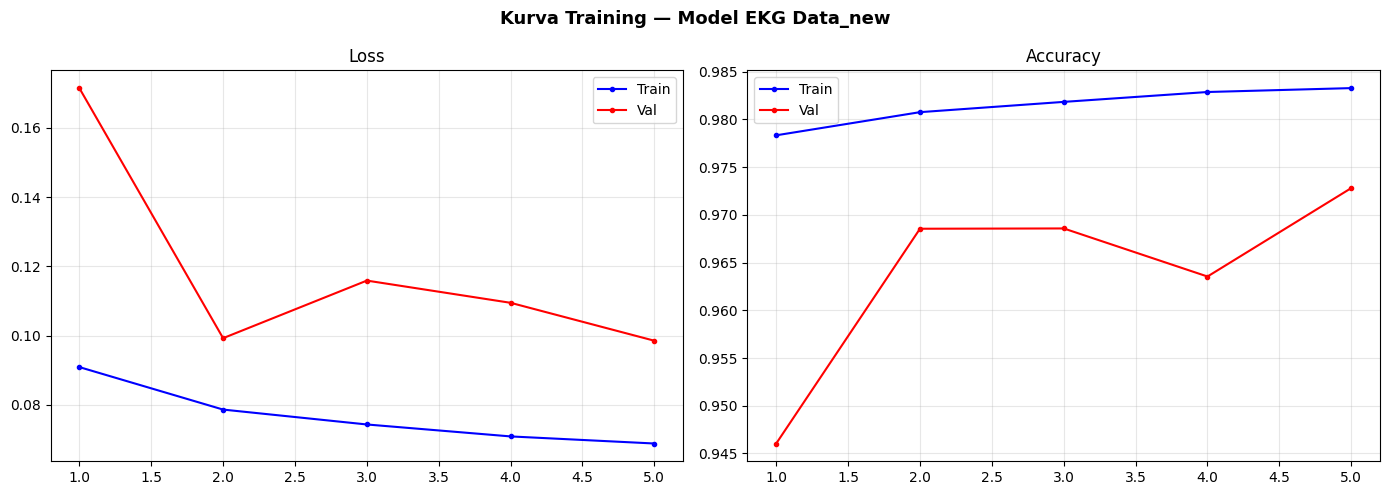


=== Classification Report (EKG) ===
              precision    recall  f1-score   support

         NSR       1.00      0.97      0.99    959135
        AFib       0.73      1.00      0.84     74751

    accuracy                           0.97   1033886
   macro avg       0.86      0.99      0.91   1033886
weighted avg       0.98      0.97      0.97   1033886



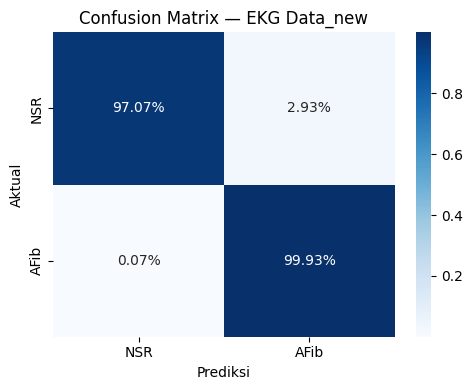


✅ Selesai! Model: c:\Users\Farel\Documents\Kuliah\Project\Cerevia\Model\model_ekg_datanew.keras


In [10]:
# =====================================================================
# SEL 7: EVALUASI & SIMPAN METADATA
# =====================================================================

nama_list = [NAMA_KELAS[k] for k in range(N_KELAS)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Kurva Training — Model EKG Data_new', fontsize=13, fontweight='bold')
ep = range(1, len(history.history['loss']) + 1)
for i, (m, t) in enumerate([('loss', 'Loss'), ('accuracy', 'Accuracy')]):
    axes[i].plot(ep, history.history[m],          'b-o', ms=3, label='Train')
    axes[i].plot(ep, history.history[f'val_{m}'], 'r-o', ms=3, label='Val')
    axes[i].set_title(t); axes[i].legend(); axes[i].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'kurva_training_ekg_datanew.png'), dpi=150, bbox_inches='tight')
plt.show()

best   = tf.keras.models.load_model(MODEL_OUT, custom_objects={'ClassToken': ClassToken})
y_pred = np.argmax(best.predict(ds_val, verbose=0), axis=1)
print('\n=== Classification Report (EKG) ===')
print(classification_report(y_val, y_pred, target_names=nama_list))

cm = confusion_matrix(y_val, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm / cm.sum(axis=1, keepdims=True), annot=True, fmt='.2%',
            cmap='Blues', xticklabels=nama_list, yticklabels=nama_list, ax=ax)
ax.set_title('Confusion Matrix — EKG Data_new')
ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'confusion_matrix_ekg_datanew.png'), dpi=150, bbox_inches='tight')
plt.show()

# Simpan metadata untuk notebook PPG
with open(os.path.join(MODEL_DIR, 'ekg_datanew_meta.json'), 'w') as f:
    json.dump({'n_kelas': N_KELAS, 'nama_kelas': NAMA_KELAS,
               'window_size': WINDOW_SIZE, 'fs_ecg': FS_ECG}, f, indent=2)
print(f'\n✅ Selesai! Model: {MODEL_OUT}')